In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import warnings
warnings.filterwarnings("ignore")

sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)

In [4]:
# 2. Load & Prepare Dataset
# ----------------------------
# Air Passengers Dataset
df = pd.read_csv("AirPassengers.csv")

df["Month"] = pd.to_datetime(df["Month"])
df.set_index("Month", inplace=True)
df.columns = ["Passengers"]

print(df.head())

            Passengers
Month                 
1949-01-01         112
1949-02-01         118
1949-03-01         132
1949-04-01         129
1949-05-01         121


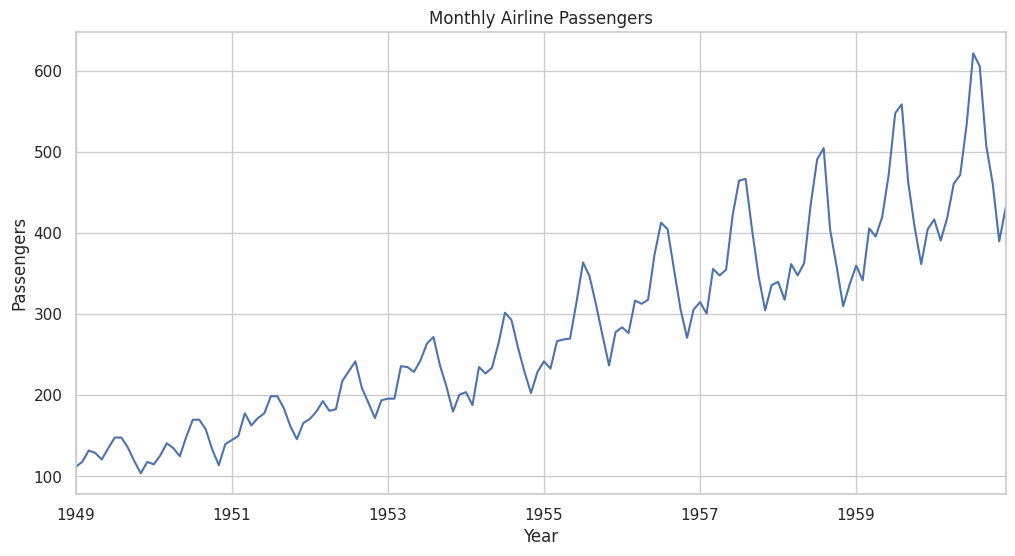

In [5]:
# 3. Visualize Time Series
# ----------------------------
df["Passengers"].plot()
plt.title("Monthly Airline Passengers")
plt.xlabel("Year")
plt.ylabel("Passengers")
plt.show()

In [6]:
# 4. Train-Test Split
# ----------------------------
train_size = int(len(df) * 0.85)
train = df.iloc[:train_size]
test = df.iloc[train_size:]

print("Train Size:", len(train))
print("Test Size:", len(test))

Train Size: 122
Test Size: 22


In [8]:
# PART A: ARIMA MODEL
# ============================================================

# ----------------------------
# 5. Auto ARIMA Model
# ----------------------------
!pip install pmdarima
import pmdarima as pm

arima_model = pm.auto_arima(
    train["Passengers"],
    seasonal=True,
    m=12,
    stepwise=True,
    suppress_warnings=True,
    trace=True
)

print(arima_model.summary())


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 689.1/689.1 kB 24.8 MB/s eta 0:00:00
Performing stepwise search to minimize aic
 ARIMA(2,0,2)(1,1,1)[12] intercept   : AIC=828.367, Time=2.30 sec
 ARIMA(0,0,0)(0,1,0)[12] intercept   : AIC=925.335, Time=0.04 sec
 ARIMA(1,0,0)(1,1,0)[12] intercept   : AIC=825.304, Time=0.48 sec
 ARIMA(0,0,1)(0,1,1)[12] intercept   : AIC=874.486, Time=0.43 sec
 ARIMA(0,0,0)(0,1,0)[12]             : AIC=1078.999, Time=0.04 sec
 ARIMA(1,0,0)(0,1,0)[12] intercept   : AIC=824.210, Time=0.14 sec
 ARIMA(1,0,0)(0,1,1)[12] intercept   : AIC=825.394, Time=0.78 sec
 ARIMA(1,0,0)(1,1,1)[12] intercept   : AIC=826.953, Time=3.44 sec
 ARIMA(2,0,0)(0,1,0)[12] intercept   : AIC=824.031, Time=0.17 sec
 ARIMA(2,0,0)(1,1,0)[12] intercept   : AIC=825.453, Time=0.65 sec
 ARIMA(2,0,0)(0,1,1)[12] intercept   : AIC=825.555, Time=0.44 sec
 ARIMA(2,0,0)(1,1,1)[12] intercept   : AIC=inf, Time=1.49 sec
 ARIMA(3,0,0)(0,1,0)[12] intercept   : AIC=824.576, Time=0.29 sec
 ARIMA(2,0,1)(0,1,0)[

In [9]:
# 6. ARIMA Forecast
# ----------------------------
arima_forecast = arima_model.predict(n_periods=len(test))
arima_forecast = pd.Series(
    arima_forecast,
    index=test.index
)

In [10]:
# 7. ARIMA Evaluation
# ----------------------------
arima_mae = mean_absolute_error(test, arima_forecast)
arima_rmse = np.sqrt(mean_squared_error(test, arima_forecast))

print("ARIMA MAE:", arima_mae)
print("ARIMA RMSE:", arima_rmse)


ARIMA MAE: 36.0902012103423
ARIMA RMSE: 39.86657161685751


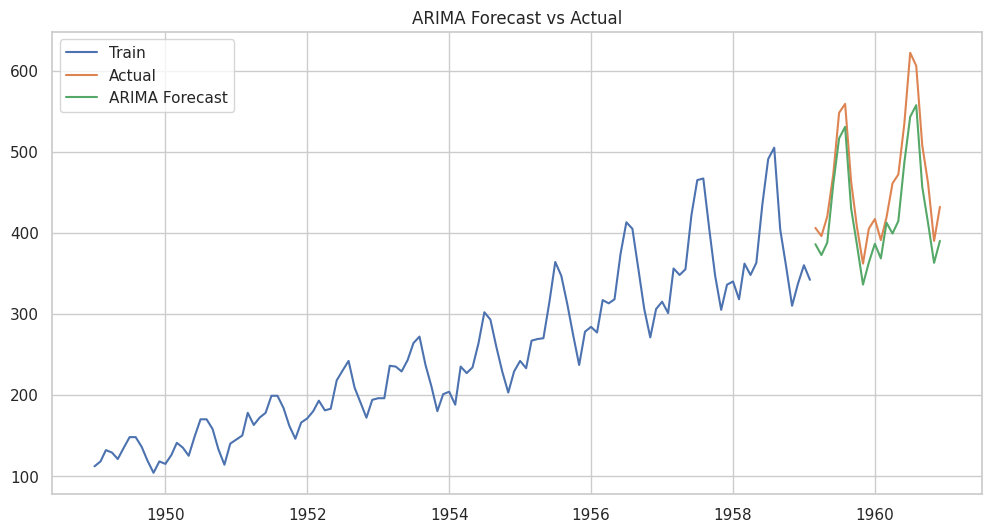

In [11]:
# 8. ARIMA Forecast Plot
# ----------------------------
plt.plot(train, label="Train")
plt.plot(test, label="Actual")
plt.plot(arima_forecast, label="ARIMA Forecast")
plt.title("ARIMA Forecast vs Actual")
plt.legend()
plt.show()



In [12]:
# PART B: PROPHET MODEL
# ============================================================

# ----------------------------
# 9. Prepare Data for Prophet
# ----------------------------
from prophet import Prophet

df_prophet = df.reset_index().rename(
    columns={"Month": "ds", "Passengers": "y"}
)

train_prophet = df_prophet.iloc[:train_size]
test_prophet = df_prophet.iloc[train_size:]


In [13]:
# 10. Train Prophet Model
# ----------------------------
prophet_model = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=False,
    daily_seasonality=False
)

prophet_model.fit(train_prophet)



In [14]:
# 11. Prophet Forecast
# ----------------------------
future = prophet_model.make_future_dataframe(
    periods=len(test_prophet),
    freq="M"
)

forecast = prophet_model.predict(future)

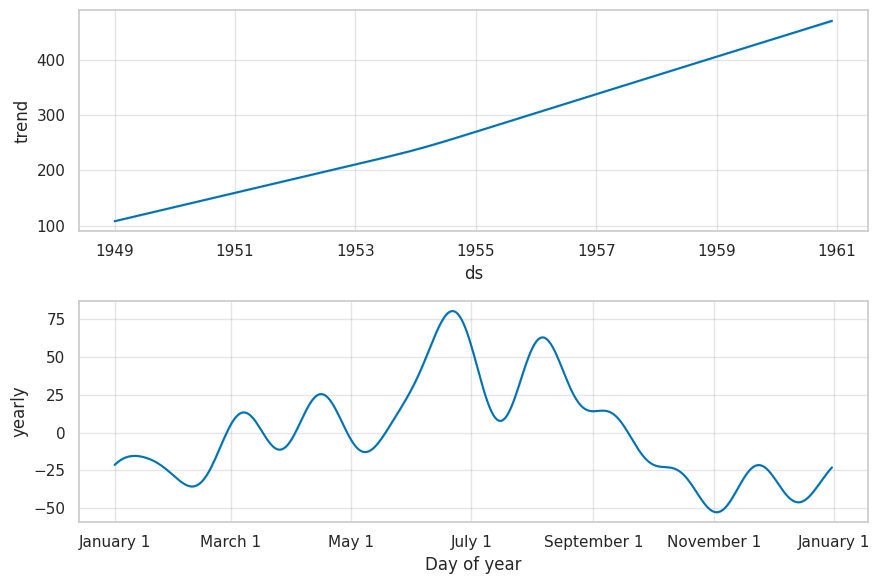

In [15]:
# 12. Prophet Components
# ----------------------------
prophet_model.plot_components(forecast)
plt.show()

In [16]:
# 13. Prophet Evaluation
# ----------------------------
prophet_preds = forecast.iloc[train_size:]["yhat"].values

prophet_mae = mean_absolute_error(test_prophet["y"], prophet_preds)
prophet_rmse = np.sqrt(mean_squared_error(test_prophet["y"], prophet_preds))

print("Prophet MAE:", prophet_mae)
print("Prophet RMSE:", prophet_rmse)


Prophet MAE: 30.797451014631882
Prophet RMSE: 42.27790313867706


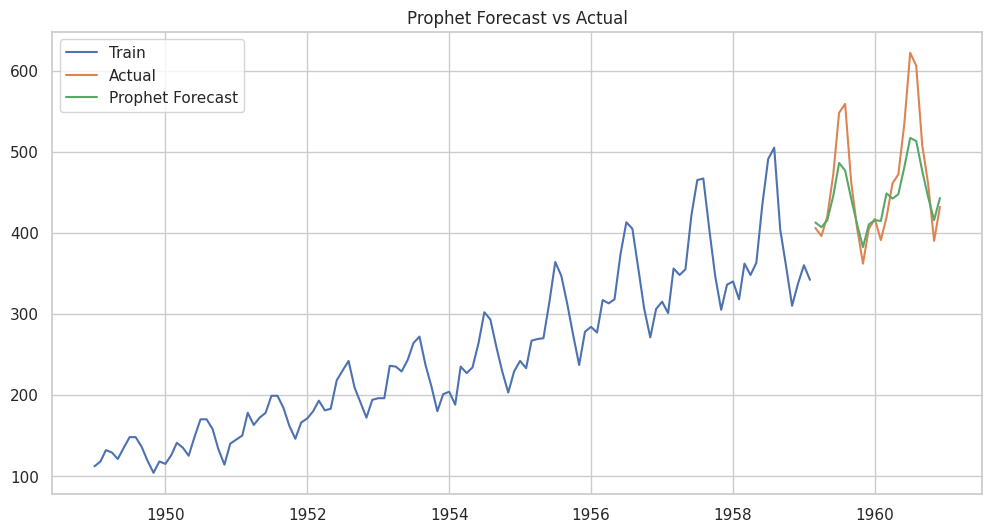

In [17]:
# 14. Prophet Forecast Plot
# ----------------------------
plt.plot(train.index, train["Passengers"], label="Train")
plt.plot(test.index, test["Passengers"], label="Actual")
plt.plot(test.index, prophet_preds, label="Prophet Forecast")
plt.title("Prophet Forecast vs Actual")
plt.legend()
plt.show()

In [19]:
# 15. Model Comparison
# ============================================================
comparison = pd.DataFrame({
    "Model": ["ARIMA", "Prophet"],
    "MAE": [arima_mae, prophet_mae],
    "RMSE": [arima_rmse, prophet_rmse]
})

print("\nModel Performance Comparison:")
print(comparison)


Model Performance Comparison:
     Model        MAE       RMSE
0    ARIMA  36.090201  39.866572
1  Prophet  30.797451  42.277903


In [20]:
# 16. Save Results
# ----------------------------
comparison.to_csv("week19_model_comparison.csv", index=False)
print("\nResults saved successfully!")



Results saved successfully!
